# Consolidated simulation study results

This notebook combines saved results from the 20 `simulation_study_s0-*` notebooks: simulated selfing rates 0.00–0.95 in steps of 0.05, census population sizes N=100, 250, and 500, and samples of n=3 and n=6 diploids (120 sample-specific summaries). Each population-size/selfing-rate combination pools 10,000 independent loci. The two sample sizes share each locus's population history and use separate random draws from its final population.

The notebook reads existing CSV outputs and writes refreshed tables and figures under `results/consolidated/`; it does not run SLiM. Result directories use `N` for census population size, and tables use `census_population_size`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
RESULTS_DIR = NOTEBOOK_DIR / "results"
CONSOLIDATED_DIR = RESULTS_DIR / "consolidated"
CONSOLIDATED_DIR.mkdir(parents=True, exist_ok=True)

pd.options.display.float_format = "{:.4f}".format
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
})


## Load saved runs

The helper reads one summary and its matching likelihood and observed-DGS tables. Run metadata are added to the two longer tables so they can be concatenated for plotting.


In [2]:
RUN_KEYS = ["n_sample_diploids", "census_population_size", "true_s"]


def load_run(summary_path):
    run_dir = summary_path.parent
    summary = pd.read_csv(summary_path).iloc[0].to_dict()
    summary["true_s"] = round(float(summary["true_s"]), 12)
    summary["run_dir"] = str(run_dir.relative_to(NOTEBOOK_DIR))
    metadata = {key: summary[key] for key in RUN_KEYS}

    likelihood = pd.read_csv(run_dir / "likelihood.csv").sort_values("s")
    likelihood["s"] = likelihood["s"].round(12)
    likelihood["delta_loglik"] = likelihood["loglik"] - likelihood["loglik"].max()
    observed = pd.read_csv(run_dir / "observed_polymorphic_dgs.csv")
    return summary, likelihood.assign(**metadata), observed.assign(**metadata)


summary_paths = sorted(RESULTS_DIR.glob("joint_s*/N*/n*/validation_summary.csv"))
if not summary_paths:
    raise FileNotFoundError(f"No simulation outputs found under {RESULTS_DIR}")

runs = [load_run(path) for path in summary_paths]
validation = pd.DataFrame(run[0] for run in runs).sort_values(RUN_KEYS).reset_index(drop=True)
likelihoods = pd.concat((run[1] for run in runs), ignore_index=True).sort_values(RUN_KEYS + ["s"])
observed_dgs = pd.concat((run[2] for run in runs), ignore_index=True).sort_values(RUN_KEYS + ["n0", "n1", "n2"])


## Check completeness and consistency

These checks confirm that all 120 study combinations are present and that each summary agrees with its likelihood and DGS tables.


In [3]:
SELFING_GRID = np.round(np.arange(20) * 0.05, 12)
expected_runs = pd.MultiIndex.from_product(
    [[3, 6], [100, 250, 500], SELFING_GRID], names=RUN_KEYS
)
actual_runs = pd.MultiIndex.from_frame(validation[RUN_KEYS])

likelihood_grids = likelihoods.groupby(RUN_KEYS)["s"].apply(
    lambda values: np.array_equal(values.to_numpy(), SELFING_GRID)
)
optima = (
    likelihoods.loc[likelihoods.groupby(RUN_KEYS)["loglik"].idxmax(), RUN_KEYS + ["s", "loglik"]]
    .rename(columns={"s": "likelihood_best_s", "loglik": "likelihood_best_loglik"})
)
site_totals = observed_dgs.groupby(RUN_KEYS)["count"].sum().rename("observed_n_sites")
checks = validation.merge(optima, on=RUN_KEYS).merge(site_totals, on=RUN_KEYS)

assert actual_runs.is_unique and set(actual_runs) == set(expected_runs)
assert validation["n_loci"].eq(10_000).all() and likelihood_grids.all()
assert np.isfinite(likelihoods["loglik"]).all()
assert np.allclose(checks["best_s"], checks["likelihood_best_s"])
assert np.allclose(checks["best_loglik"], checks["likelihood_best_loglik"])
assert checks["n_sites"].eq(checks["observed_n_sites"]).all()
assert checks["boundary_optimum"].eq(checks["best_s"].isin(SELFING_GRID[[0, -1]])).all()
print("All 120 runs passed completeness and consistency checks.")


All 120 runs passed completeness and consistency checks.


## Write consolidated tables

The combined tables below are the inputs to the summaries and figures that follow.


In [4]:
validation["estimation_error"] = validation["best_s"] - validation["true_s"]
validation.loc[np.isclose(validation["estimation_error"], 0.0, atol=1e-12), "estimation_error"] = 0.0
validation["abs_error"] = validation["estimation_error"].abs()

tables = {
    "consolidated_validation_summary.csv": validation,
    "consolidated_likelihoods.csv": likelihoods,
    "consolidated_observed_polymorphic_dgs.csv": observed_dgs,
}
for filename, table in tables.items():
    table.to_csv(CONSOLIDATED_DIR / filename, index=False)

print(f"Loaded {len(validation)} summaries and {len(likelihoods):,} likelihood rows.")
display(validation[RUN_KEYS + ["best_s", "n_sites", "n_loci", "boundary_optimum"]].head())


Loaded 120 summaries and 2,400 likelihood rows.


,n_sample_diploids,census_population_size,true_s,best_s,n_sites,n_loci,boundary_optimum
0,3,100,0.0000,0.0000,932,10000,True
1,3,100,0.0500,0.0000,881,10000,True
2,3,100,0.1000,0.1000,898,10000,False
3,3,100,0.1500,0.2000,826,10000,False
4,3,100,0.2000,0.1500,815,10000,False


## Summary table

Errors compare the best candidate grid value with the simulated selfing rate. Each row summarizes 20 different simulated rates; these are not replicate estimates at a fixed rate. `boundary_runs` counts optima at either end of the evaluated grid (0.00 or 0.95), including runs simulated at those endpoints. Floating-point differences below 1e-12 are treated as zero.


In [5]:
performance_summary = (
    validation.groupby(["n_sample_diploids", "census_population_size"], as_index=False)
    .agg(
        n_runs=("true_s", "size"),
        mean_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
        mean_error=("estimation_error", "mean"),
        boundary_runs=("boundary_optimum", "sum"),
        mean_polymorphic_sites=("n_sites", "mean"),
    )
)
performance_summary.to_csv(CONSOLIDATED_DIR / "consolidated_performance_summary.csv", index=False)
display(performance_summary)

,n_sample_diploids,census_population_size,n_runs,mean_abs_error,max_abs_error,mean_error,boundary_runs,mean_polymorphic_sites
0,3,100,20,0.0200,0.1000,-0.0150,3,638.1000
1,3,250,20,0.0075,0.0500,-0.0075,3,1562.9500
2,3,500,20,0.0050,0.0500,0.0050,1,3170.1000
3,6,100,20,0.0100,0.0500,-0.0100,2,872.7500
4,6,250,20,0.0025,0.0500,-0.0025,2,2148.5500
5,6,500,20,0.0000,0.0000,0.0000,2,4316.5500


## Recovery summary figure

The first figure summarizes the fitted selfing rate, the signed estimation error, and the number of polymorphic sites used in the likelihood. Each row is a sample size and each line is a census population size.

Saved /n/holylfs05/LABS/hopkins_lab/Users/pfmckenzie/projects/selfing_slim/dgs_manuscript/validation/manuscript_simulation_check/results/consolidated/consolidated_selfing_recovery.png
Saved /n/holylfs05/LABS/hopkins_lab/Users/pfmckenzie/projects/selfing_slim/dgs_manuscript/validation/manuscript_simulation_check/results/consolidated/consolidated_selfing_recovery.pdf


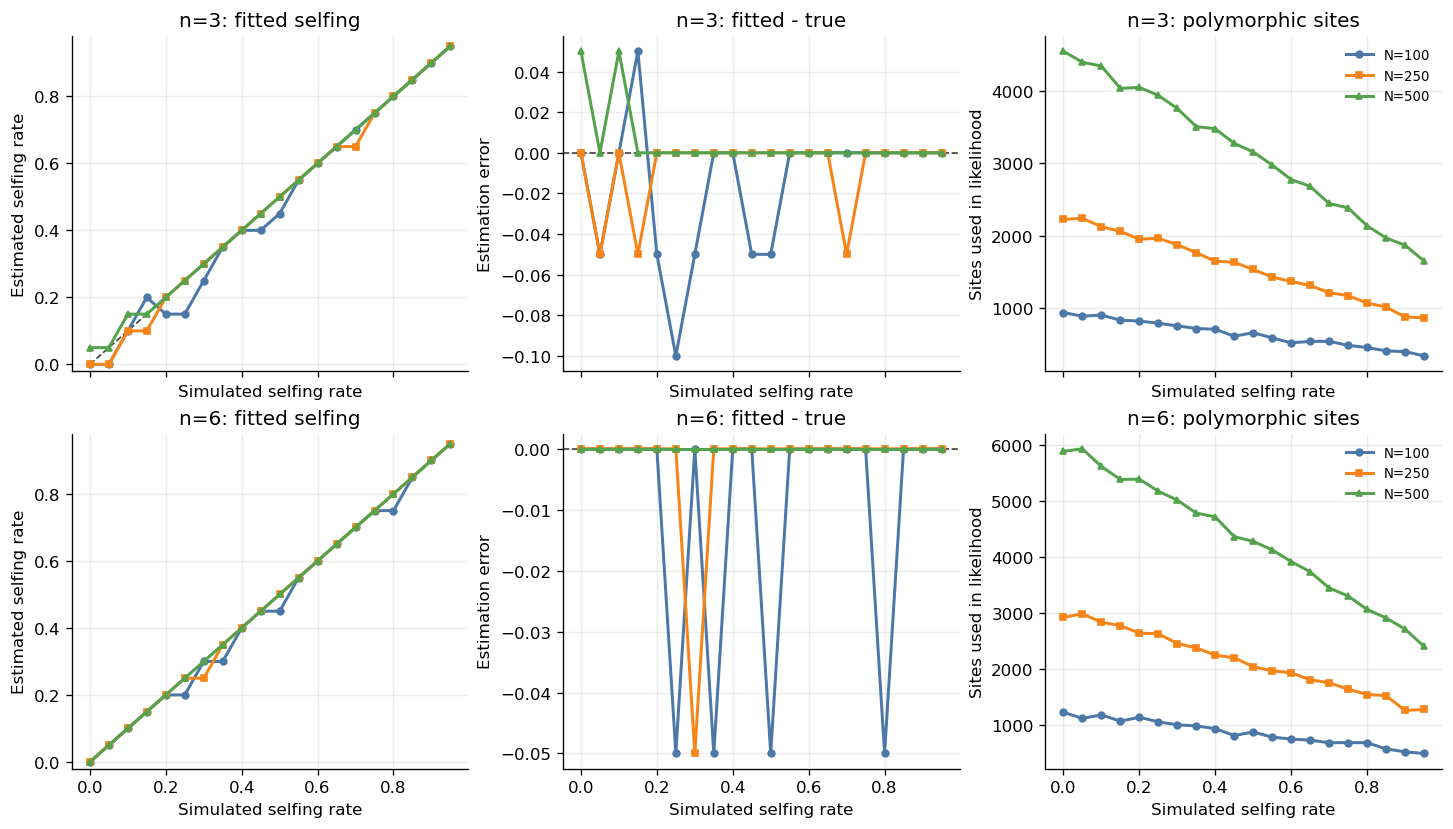

In [6]:
sample_sizes = sorted(validation["n_sample_diploids"].unique())
population_sizes = sorted(validation["census_population_size"].unique())
colors = dict(zip(population_sizes, ["#4c78a8", "#f58518", "#54a24b", "#b279a2", "#e45756", "#72b7b2"]))
markers = dict(zip(population_sizes, ["o", "s", "^", "D", "v", "P"]))

fig, axes = plt.subplots(
    len(sample_sizes),
    3,
    figsize=(12, 3.4 * len(sample_sizes)),
    squeeze=False,
    constrained_layout=True,
    sharex="col",
)

for row_index, n_sample in enumerate(sample_sizes):
    row = validation.loc[validation["n_sample_diploids"] == n_sample].copy()
    ax_fit, ax_error, ax_sites = axes[row_index]

    min_s = float(row["true_s"].min())
    max_s = float(row["true_s"].max())
    ax_fit.plot([min_s, max_s], [min_s, max_s], color="0.25", linestyle="--", linewidth=1, label="1:1")
    ax_error.axhline(0, color="0.25", linestyle="--", linewidth=1)

    for population_size in population_sizes:
        sub = row.loc[row["census_population_size"] == population_size].sort_values("true_s")
        if sub.empty:
            continue
        label = f"N={population_size}"
        ax_fit.plot(sub["true_s"], sub["best_s"], marker=markers[population_size], color=colors[population_size], linewidth=1.8, markersize=4, label=label)
        ax_error.plot(sub["true_s"], sub["estimation_error"], marker=markers[population_size], color=colors[population_size], linewidth=1.8, markersize=4, label=label)
        ax_sites.plot(sub["true_s"], sub["n_sites"], marker=markers[population_size], color=colors[population_size], linewidth=1.8, markersize=4, label=label)

    ax_fit.set_title(f"n={n_sample}: fitted selfing")
    ax_fit.set_ylabel("Estimated selfing rate")
    ax_fit.set_ylim(-0.02, 0.98)

    ax_error.set_title(f"n={n_sample}: fitted - true")
    ax_error.set_ylabel("Estimation error")

    ax_sites.set_title(f"n={n_sample}: polymorphic sites")
    ax_sites.set_ylabel("Sites used in likelihood")
    ax_sites.legend(frameon=False, fontsize=8)

    for ax in (ax_fit, ax_error, ax_sites):
        ax.set_xlabel("Simulated selfing rate")
        ax.grid(alpha=0.25)

figure_base = CONSOLIDATED_DIR / "consolidated_selfing_recovery"
fig.savefig(figure_base.with_suffix(".png"))
fig.savefig(figure_base.with_suffix(".pdf"))
print(f"Saved {figure_base.with_suffix('.png')}")
print(f"Saved {figure_base.with_suffix('.pdf')}")
plt.show()

## Likelihood grid heatmap

Each tile shows a saved candidate-rate evaluation (x-axis) for a simulated selfing rate (y-axis). Relative log likelihood is normalized to zero separately within each simulated-rate row and clipped at −80 for display. Tiles show the evaluated grid without interpolation or smoothing. The dashed diagonal marks candidate rates equal to the simulated rates; circles mark the fitted grid optima.


Saved /n/holylfs05/LABS/hopkins_lab/Users/pfmckenzie/projects/selfing_slim/dgs_manuscript/validation/manuscript_simulation_check/results/consolidated/consolidated_likelihood_surface.png
Saved /n/holylfs05/LABS/hopkins_lab/Users/pfmckenzie/projects/selfing_slim/dgs_manuscript/validation/manuscript_simulation_check/results/consolidated/consolidated_likelihood_surface.pdf


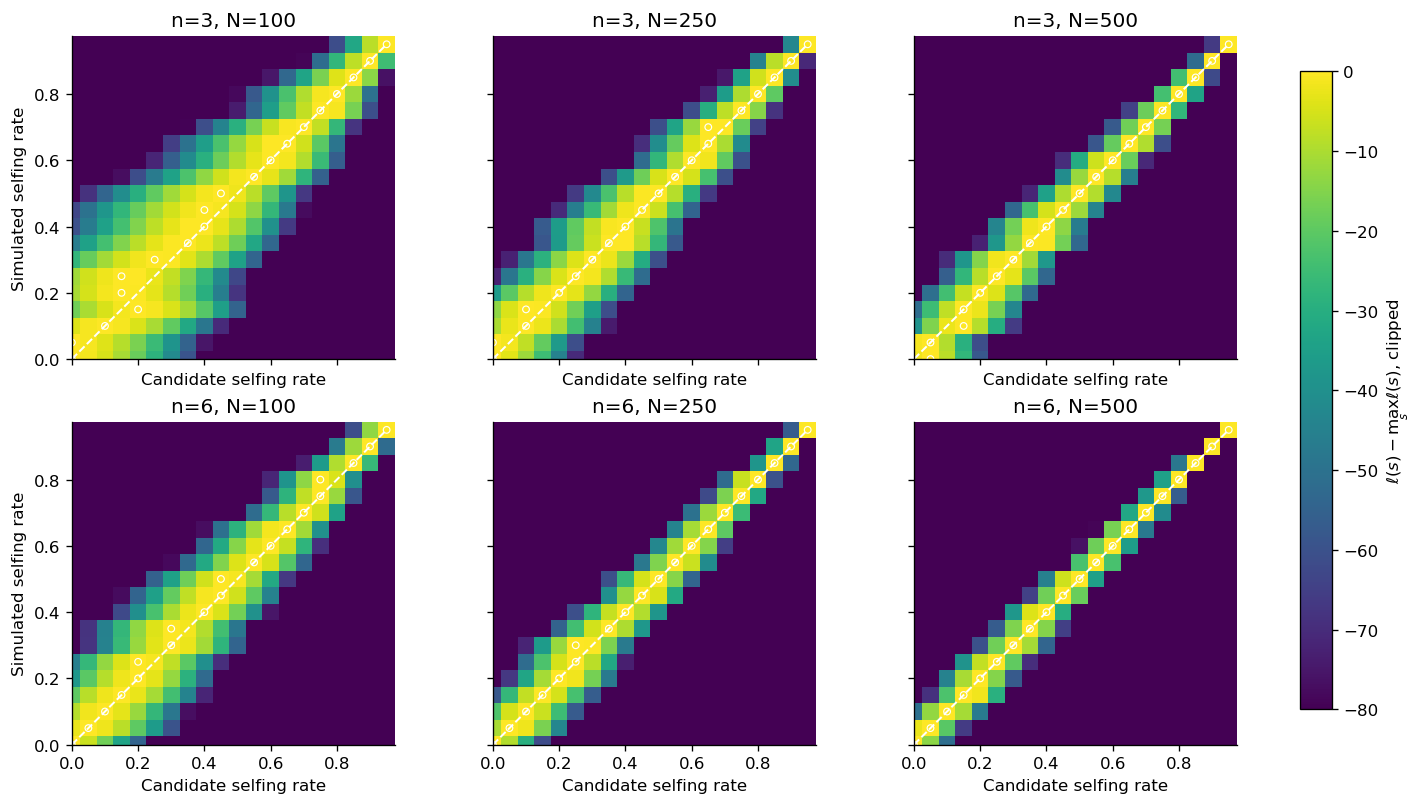

In [7]:
HEATMAP_FLOOR = -80.0

fig, axes = plt.subplots(
    len(sample_sizes),
    len(population_sizes),
    figsize=(4.0 * len(population_sizes), 3.3 * len(sample_sizes)),
    squeeze=False,
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

last_image = None
for row_index, n_sample in enumerate(sample_sizes):
    for col_index, population_size in enumerate(population_sizes):
        ax = axes[row_index, col_index]
        sub = likelihoods.loc[(likelihoods["n_sample_diploids"] == n_sample) & (likelihoods["census_population_size"] == population_size)].copy()
        if sub.empty:
            ax.set_axis_off()
            continue

        surface = (
            sub.pivot(index="true_s", columns="s", values="delta_loglik")
            .sort_index()
            .sort_index(axis=1)
        )
        values = np.clip(surface.to_numpy(dtype=float), HEATMAP_FLOOR, 0.0)
        x_values = surface.columns.to_numpy(dtype=float)
        y_values = surface.index.to_numpy(dtype=float)

        last_image = ax.pcolormesh(
            x_values, y_values, values, shading="nearest",
            cmap="viridis", vmin=HEATMAP_FLOOR, vmax=0.0,
        )
        fitted = validation.loc[
            (validation["n_sample_diploids"] == n_sample)
            & (validation["census_population_size"] == population_size)
        ].sort_values("true_s")
        ax.scatter(fitted["best_s"], fitted["true_s"], s=16,
                   facecolors="none", edgecolors="white", linewidths=0.7)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(max(0.0, x_values.min() - 0.025), min(1.0, x_values.max() + 0.025))
        ax.set_ylim(max(0.0, y_values.min() - 0.025), min(1.0, y_values.max() + 0.025))
        diagonal_min = max(x_values.min(), y_values.min())
        diagonal_max = min(x_values.max(), y_values.max())
        ax.plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], color="white", linestyle="--", linewidth=1.2)
        ax.set_title(f"n={n_sample}, N={population_size}")
        ax.set_xlabel("Candidate selfing rate")
        if col_index == 0:
            ax.set_ylabel("Simulated selfing rate")

if last_image is not None:
    colorbar = fig.colorbar(last_image, ax=axes, shrink=0.9)
    colorbar.set_label(r"$\ell(s)-\max_s \ell(s)$, clipped")

figure_base = CONSOLIDATED_DIR / "consolidated_likelihood_surface"
fig.savefig(figure_base.with_suffix(".png"))
fig.savefig(figure_base.with_suffix(".pdf"))
print(f"Saved {figure_base.with_suffix('.png')}")
print(f"Saved {figure_base.with_suffix('.pdf')}")
plt.show()

In [8]:
import platform
import matplotlib

print(f"Python version:     {platform.python_version()}")
print(f"NumPy version:      {np.__version__}")
print(f"pandas version:     {pd.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")


Python version:     3.12.11
NumPy version:      2.5.1
pandas version:     2.3.0
Matplotlib version: 3.10.6
